Numerical peak frequency: 3.67967e+07 Hz
Analytic resonance estimate: 3.67847e+07 Hz
Peak magnitude: 24.1086 dB
Peak frequency: 3.67967e+07 Hz
Peak magnitude: 24.1086 dB
Estimated Q: 68.96
Lower -3 dB frequency: 3.65361e+07 Hz
Upper -3 dB frequency: 3.70696e+07 Hz


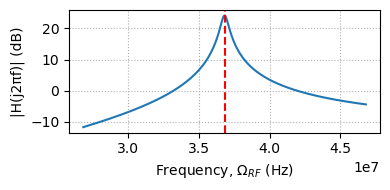

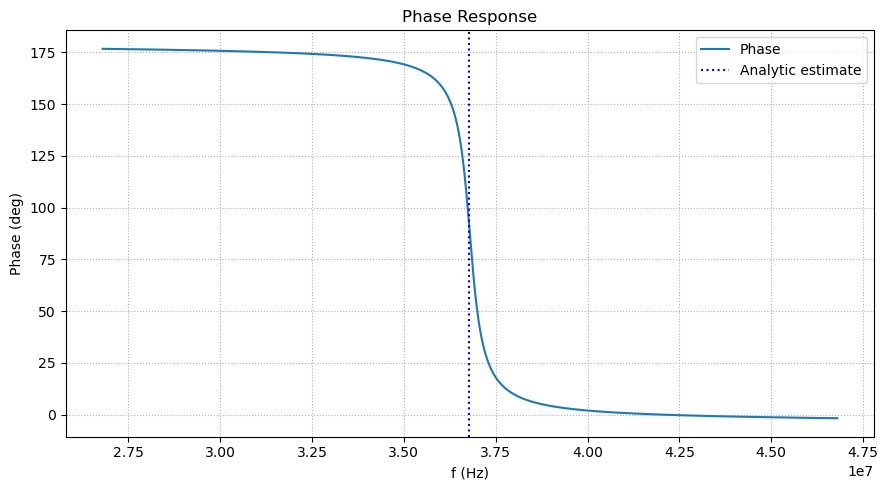

In [184]:
import numpy as np
import matplotlib.pyplot as plt

# Transfer function for:
# Vin -> Rs -> C -> node V1
# V1  -> L to ground
# V1  -> (RL in series with CL) to ground

def H_jw(f, C, L, Rs, RL, CL):
    w = 2 * np.pi * f
    s = 1j * w

    ZL = RL + 1 / (s * CL)
    Zp = 1 / (1 / (s * L) + 1 / ZL)   # sL || ZL
    Zs = Rs + 1 / (s * C)             # Rs + series C

    return Zp / (Zs + Zp)


# ---- User parameters ----
Cval = 5.4e-12
Lval = 0.8e-6
Rsval = 50
RLval = 0.0
CLval = 18e-12


# Frequency range
fmin = 3.68e7-1e7
fmax = 3.68e7+1e7
f = np.logspace(np.log10(fmin), np.log10(fmax), 4000)

# Response
H = H_jw(f, Cval, Lval, Rsval, RLval, CLval)
mag_db = 20 * np.log10(np.abs(H))
phase_deg = np.angle(H, deg=True)

# Analytic estimate
f_analytic = 1 / (2 * np.pi * np.sqrt(Lval * (Cval + CLval)))

# Numerical peak from magnitude
idx_peak = np.argmax(mag_db)
f_peak = f[idx_peak]
mag_peak = mag_db[idx_peak]

print(f"Numerical peak frequency: {f_peak:.6g} Hz")
print(f"Analytic resonance estimate: {f_analytic:.6g} Hz")
print(f"Peak magnitude: {mag_peak:.6g} dB")

# ---- Plot magnitude ----
fig_width = 5.827 /3
fig_height = 5.827 /3
fig, ax = plt.subplots(figsize=(4, 2))
ax.plot(f, mag_db, label="Magnitude")
ax.axvline(f_peak, color="red", linestyle="--", linewidth=1.5, label="Numerical peak")
#ax.axvline(f_analytic, color="blue", linestyle=":", linewidth=1.5, label="Analytic estimate")
ax.set_xlabel("Frequency, $\\Omega_{RF}$ (Hz)")
ax.set_ylabel("|H(j2πf)| (dB)")
ax.grid(True, which="both", ls=":")
plt.tight_layout()
path = "../../../pdf_figure/ch2/res_H.pdf"
# plt.savefig(path)

# ---- Plot phase ----
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(f, phase_deg, label="Phase")
#ax.axvline(f_peak, color="red", linestyle="--", linewidth=1.5, label="Numerical peak")
ax.axvline(f_analytic, color="blue", linestyle=":", linewidth=1.5, label="Analytic estimate")
ax.set_xlabel("f (Hz)")
ax.set_ylabel("Phase (deg)")
ax.set_title("Phase Response")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()

def get_Q(f, mag_db):
    # Find the peak magnitude and frequency
    idx_peak = np.argmax(mag_db)
    f_peak = f[idx_peak]
    mag_peak = mag_db[idx_peak]
    print(f"Peak frequency: {f_peak:.6g} Hz")
    print(f"Peak magnitude: {mag_peak:.6g} dB")

    # Calculate the -3 dB point
    mag_3db = mag_peak - 3

    # Find frequencies where magnitude crosses the -3 dB point
    idx_below = np.where(mag_db < mag_3db)[0]

    # take largest index below peak and smallest index above peak
    idx_lower = np.max(idx_below[idx_below < idx_peak])
    idx_upper = np.min(idx_below[idx_below > idx_peak])


    if len(idx_below) < 2:
        print("Not enough points below -3 dB to calculate Q.")
        return None

    # Get the frequencies at the -3 dB points
    f_lower = f[idx_lower]
    f_upper = f[idx_upper]

    # Calculate bandwidth and Q
    bandwidth = f_upper - f_lower
    Q = f_peak / bandwidth

    return Q, f_lower, f_upper
Q, f_lower, f_upper = get_Q(f, mag_db)
print(f"Estimated Q: {Q:.2f}")
print(f"Lower -3 dB frequency: {f_lower:.6g} Hz")
print(f"Upper -3 dB frequency: {f_upper:.6g} Hz")

Carrier frequency f0 = 3.67847e+07 Hz


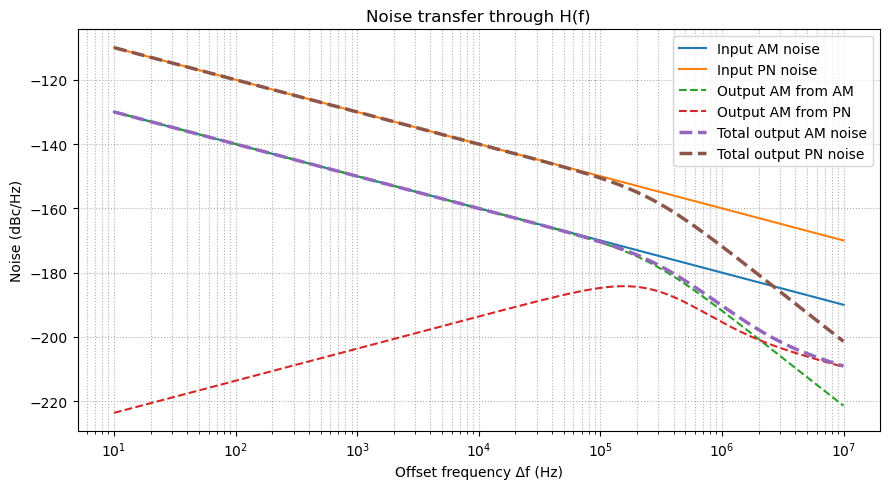

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Transfer function
# ----------------------------
def H_jw(f, C, L, Rs, RL, CL):
    """
    Complex transfer function H(j2πf) for:
      Vin -> Rs -> C -> node V1
      V1 -> L to ground
      V1 -> (RL in series with CL) to ground
    """
    w = 2 * np.pi * np.asarray(f)
    s = 1j * w

    ZL = RL + 1 / (s * CL)
    Zp = 1 / (1 / (s * L) + 1 / ZL)   # sL || ZL
    Zs = Rs + 1 / (s * C)             # Rs + series C

    return Zp / (Zs + Zp)


# ----------------------------
# Noise conversion
# ----------------------------
def am_noise_after_filter(
    offsets_hz,
    carrier_hz,
    H_func,
    H_args,
    am_in_dbc_per_hz=None,
    pn_in_dbc_per_hz=None,
):
    """
    Compute output AM noise spectrum in dBc/Hz from input AM and PN spectra.

    Parameters
    ----------
    offsets_hz : array_like
        Noise offset frequencies Δf (Hz), positive.
    carrier_hz : float
        Carrier frequency f0 (Hz).
    H_func : callable
        Function H(f, *H_args) returning complex transfer function at frequency f.
    H_args : tuple
        Extra arguments for H_func.
    am_in_dbc_per_hz : array_like or None
        Input AM noise spectrum in dBc/Hz.
    pn_in_dbc_per_hz : array_like or None
        Input phase-noise spectrum in dBc/Hz.
    """
    offsets_hz = np.asarray(offsets_hz, dtype=float)
    H0 = H_func(carrier_hz, *H_args)
    Hp = H_func(carrier_hz + offsets_hz, *H_args)
    Hm = H_func(np.maximum(carrier_hz - offsets_hz, 1e-30), *H_args)

    Gp = Hp / H0
    Gm = Hm / H0

    g_aa = 0.5 * (Gp + np.conj(Gm))      # AM -> AM
    g_pa = 0.5j * (Gp - np.conj(Gm))     # PM -> AM
    g_pp = 0.5 * (Gp + np.conj(Gm))      # PM -> PM
    g_ap = 0.5j * (Gp - np.conj(Gm))     # AM -> PM (not used here)


    am_out_lin = np.zeros_like(offsets_hz, dtype=float)
    pn_out_lin = np.zeros_like(offsets_hz, dtype=float)

    if am_in_dbc_per_hz is not None:
        am_lin = 10 ** (np.asarray(am_in_dbc_per_hz) / 10.0)
        am_out_lin += am_lin * np.abs(g_aa) ** 2

    if pn_in_dbc_per_hz is not None:
        pn_lin = 10 ** (np.asarray(pn_in_dbc_per_hz) / 10.0)
        am_out_lin += pn_lin * np.abs(g_pa) ** 2
        pn_out_lin += pn_lin * np.abs(g_pp) ** 2

    return 10 * np.log10(am_out_lin), g_aa, g_pa, 10 * np.log10(pn_out_lin)


# ----------------------------
# Example parameters
# ----------------------------

# Pick a carrier near the resonance for demonstration
f0 = 1 / (2 * np.pi * np.sqrt(Lval * (Cval + CLval)))

# Offset frequencies for noise plot
offsets = np.logspace(1, 7, 1000)   # 10 Hz to 10 MHz

# Simple white noise models (flat spectra)
am_in = -120.0 * np.ones_like(offsets)   # dBc/Hz
pn_in = -100.0 * np.ones_like(offsets)   # dBc/Hz
# pink noise (-3 dB/decade) example:
am_in = -120.0 - 10 * np.log10(offsets) 
pn_in = -100.0 - 10 * np.log10(offsets)

# Output AM noise from both sources
am_out, g_aa, g_pa, pn_out = am_noise_after_filter(
    offsets_hz=offsets,
    carrier_hz=f0,
    H_func=H_jw,
    H_args=(Cval, Lval, Rsval, RLval, CLval),
    am_in_dbc_per_hz=am_in,
    pn_in_dbc_per_hz=pn_in,
)

# Also show individual contributions
H0 = H_jw(f0, Cval, Lval, Rsval, RLval, CLval)
Hp = H_jw(f0 + offsets, Cval, Lval, Rsval, RLval, CLval)
Hm = H_jw(np.maximum(f0 - offsets, 1e-30), Cval, Lval, Rsval, RLval, CLval)

Gp = Hp / H0
Gm = Hm / H0

g_aa = 0.5 * (Gp + np.conj(Gm))      # AM -> AM
g_pa = 0.5j * (Gp - np.conj(Gm))     # PM -> AM

am_from_am = am_in + 10 * np.log10(np.abs(g_aa) ** 2)
am_from_pn = pn_in + 10 * np.log10(np.abs(g_pa) ** 2)

print(f"Carrier frequency f0 = {f0:.6g} Hz")

# ----------------------------
# Plots
# ----------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(offsets, am_in, label="Input AM noise")
ax.semilogx(offsets, pn_in, label="Input PN noise")
ax.semilogx(offsets, am_from_am, label="Output AM from AM", linestyle="--") 
ax.semilogx(offsets, am_from_pn, label="Output AM from PN", linestyle="--")
ax.semilogx(offsets, am_out, linewidth=2.5, label="Total output AM noise", linestyle="--")
ax.semilogx(offsets, pn_out, linewidth=2.5, label="Total output PN noise", linestyle="--")
ax.set_xlabel("Offset frequency Δf (Hz)")
ax.set_ylabel("Noise (dBc/Hz)")
ax.set_title("Noise transfer through H(f)")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()

In [100]:
import numpy as np
import csv
import matplotlib.pyplot as plt


def load_trace_data(csv_file):
    """
    Parse a phase noise CSV file and extract all traces with metadata.

    Args:
        csv_file (str): Path to the CSV file

    Returns:
        dict: Ordered dictionary with trace data and metadata
              Keys are trace names (e.g., 'Trace 1'), values are dicts with:
              - 'label': formatted label (e.g., 'PN (Smooth)')
              - 'frequencies': list of frequency values
              - 'powers': list of power values
              - 'metadata': dict with trace_result, smoothing_value, num_values
    """
    traces = {}

    with open(csv_file, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if "Trace Label," in line:
            parts = line.strip().split(",")
            if len(parts) >= 2:
                trace_name = parts[1]
                if trace_name and trace_name != "OFF":
                    # Find the "Values" line AFTER this trace label
                    for j in range(i + 1, min(i + 10, len(lines))):
                        if "Values," in lines[j]:
                            num_values = int(lines[j].strip().split(",")[1])
                            start_line = j + 1
                            end_line = start_line + num_values

                            # Find metadata BEFORE the trace label
                            trace_result = None
                            smoothing_value = None
                            for k in range(i - 1, max(0, i - 10), -1):
                                if "Trace Result," in lines[k]:
                                    trace_result = lines[k].strip().split(",")[1]
                                elif "Smoothing," in lines[k]:
                                    smoothing_parts = lines[k].strip().split(",")
                                    if len(smoothing_parts) >= 2:
                                        smoothing_value = smoothing_parts[1] == "ON"

                            # Extract trace data
                            frequencies = []
                            powers = []
                            with open(csv_file, "r") as f:
                                for idx, data_line in enumerate(f):
                                    if start_line <= idx < end_line:
                                        data_parts = data_line.strip().split(",")
                                        if len(data_parts) >= 2:
                                            try:
                                                frequencies.append(float(data_parts[0]))
                                                powers.append(float(data_parts[1]))
                                            except ValueError:
                                                pass

                            # Create label
                            if trace_result:
                                label = f"{trace_result}"
                                if smoothing_value:
                                    label += " (Smooth)"
                            else:
                                label = trace_name

                            # Store trace data
                            traces[trace_name] = {
                                "label": label,
                                "frequencies": frequencies,
                                "powers": powers,
                                "metadata": {
                                    "trace_result": trace_result,
                                    "smoothing_value": smoothing_value,
                                    "num_values": num_values,
                                },
                            }
                            break

    return traces

In [149]:
date = "2026-05-18"
file_names = [
    "squareatron",
    "amplifier", # After amplifier with Tenma DC supply, with atomic clock, sqr at 51 attenuation
    "urukul",
    "urukul_no_clock",
]
data = {}
for name in file_names:
    key = name.replace("_", " ").title()
    data[key] = load_trace_data(f"{name}.csv")

print(data.keys())

def phase_to_freq_noise(pn_dbc_per_hz, offset_hz, carrier_hz):
    """
    Convert phase noise in dBc/Hz to equivalent frequency noise in dBc/Hz.

    Parameters
    ----------
    pn_dbc_per_hz : array_like
        Phase noise spectrum in dBc/Hz.
    offset_hz : array_like
        Offset frequencies Δf (Hz).
    carrier_hz : float
        Carrier frequency f0 (Hz).

    Returns
    -------
    array_like
        Equivalent frequency noise spectrum in dBc/Hz.
    """
    pn_lin = 10 ** (np.asarray(pn_dbc_per_hz) / 10.0)
    S_f = (offset_hz ** 2) * pn_lin / (carrier_hz ** 2)
    return 10 * np.log10(S_f)

dict_keys(['Squareatron', 'Amplifier', 'Urukul', 'Urukul No Clock'])


Linear fit coefficients: [  -7.47560461 -117.00328761]


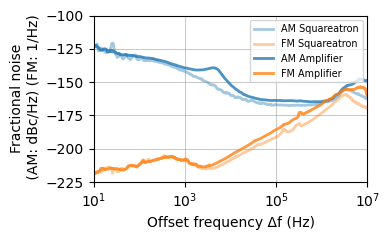

In [173]:
# Plot relevant (smoothed) amplitude noise traces

plot_keys = [
    # "Urukul No Clock",
    #"Urukul",
    "Squareatron",
    "Amplifier"
]
trace_str = "Trace 4"  # AM noise trace 
trace_str = "Trace 3"  # AM noise trace (smooth)
trace_str = "Trace 2"  # PM noise trace 
trace_str = "Trace 1"  # PM noise trace (smooth)
plt.figure(figsize=(4, 2.5))
idx = 0
for key in plot_keys:
    frequencies = data[key][trace_str]["frequencies"]
    powers = data[key]["Trace 3"]["powers"]
    phase = data[key]["Trace 1"]["powers"]
    if len(frequencies) > len(powers):
        frequencies = frequencies[: len(powers)]
        phase = phase[: len(powers)]
    plt.plot(
        frequencies,
        powers,
        label=f"AM {key}",
        alpha=0.4 if idx == 0 else 0.8,
        lw=2, 
        color="C0",
    )
    freq_noise = phase_to_freq_noise(np.array(phase), np.array(frequencies), carrier_hz=f0)
    plt.plot(
        frequencies,
        freq_noise,
        label=f"FM {key}",
        alpha=0.4 if idx == 0 else 0.8,
        lw=2,
        color="C1",
    )
    idx +=1
plt.xscale("log")
plt.xlabel("Offset frequency Δf (Hz)")
plt.ylabel("Fractional noise\n (AM: dBc/Hz) (FM: 1/Hz)")
plt.grid(True, which="major", lw=0.5)
plt.xlim(1e1, 1e7)
plt.ylim(-225, -100)

# plt.show()

lin_fit = np.polyfit(np.log10(frequencies), powers, 1)
print(f"Linear fit coefficients: {lin_fit}")

# plt.plot(
#     frequencies,
#     lin_fit[0] * np.log10(frequencies) + lin_fit[1],
#     label=f"Power law fit (slope: {lin_fit[0]:.2f})",
#     linestyle="--",
# )

plt.legend(fontsize="x-small")
path = "../../../pdf_figure/ch2/amplifier_noise.pdf"
plt.tight_layout()
plt.savefig(path)

Carrier frequency f0 = 3.67847e+07 Hz
Cutoff frequency (g_aa -3 dB point): 264241 Hz


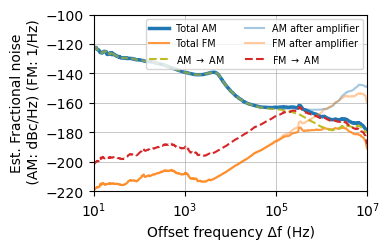

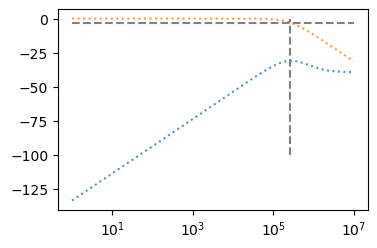

In [203]:
# Output AM noise from both sources
delta_f = 0.0e3
am_out, g_aa, g_pa, pn_out = am_noise_after_filter(
    offsets_hz=frequencies,
    carrier_hz=f0+delta_f,
    H_func=H_jw,
    H_args=(Cval, Lval, Rsval, RLval, CLval),
    am_in_dbc_per_hz=powers,
    pn_in_dbc_per_hz=phase,
)

am_from_am = powers + 10 * np.log10(np.abs(g_aa) ** 2)
am_from_pn = phase + 10 * np.log10(np.abs(g_pa) ** 2)

print(f"Carrier frequency f0 = {f0:.6g} Hz")

# ----------------------------
# Plots
# ----------------------------
plt.figure(figsize=(4, 2.6))
# ax.semilogx(frequencies, powers, label="Input AM noise")
# ax.semilogx(frequencies, phase, label="Input PN noise")
plt.plot(frequencies, am_out, label="Total AM", linestyle="-", alpha=1.0, linewidth=2.5)
fm_out = phase_to_freq_noise(pn_out, np.array(frequencies), carrier_hz=f0+delta_f)
plt.plot(frequencies, fm_out, label="Total FM", linestyle="-", alpha=0.8)
plt.plot(frequencies, am_from_am, label="AM $\\rightarrow$ AM", linestyle="--", alpha=1.0, color="C8")
# plt.plot(frequencies, phase, label="PM after amplifier", linestyle="--", alpha=0.8)
#plt after amplifier for reference
plt.plot(frequencies, powers, label="AM after amplifier", linestyle="-", alpha=0.4, color="C0")
fm = phase_to_freq_noise(np.array(phase), np.array(frequencies), carrier_hz=f0+delta_f)
plt.plot(frequencies, fm, label="FM after amplifier", linestyle="-", alpha=0.4, color="C1")
plt.plot(frequencies, am_from_pn, label="FM $\\rightarrow$ AM", linestyle="--", alpha=1.0, color="C3")
# plot g_pa
plt.xscale("log")
plt.xlabel("Offset frequency Δf (Hz)")
plt.ylabel("Est. Fractional noise\n (AM: dBc/Hz) (FM: 1/Hz)")
plt.grid(True, which="major", lw =0.5)
plt.xlim(1e1, 1e7)
plt.ylim(-220, -100)
# reduce text size of legend to tiny, have two cols
plt.legend(fontsize="x-small", ncol=2)
path = "../../../pdf_figure/ch2/res_am_noise.pdf"
plt.tight_layout()
plt.savefig(path)

plt.figure(figsize=(4, 2.6))
plt.plot(frequencies, 10 * np.log10(np.abs(g_pa) ** 2), label="|g_pa|^2 (dB)", linestyle=":", alpha=0.8)
plt.plot(frequencies, 10 * np.log10(np.abs(g_aa) ** 2), label="|g_aa|^2 (dB)", linestyle=":", alpha=0.8)
# get cut off freq of g_aa
plt.hlines(-3, frequencies[0], frequencies[-1], colors="gray", linestyles="--", label="-3 dB")
cut_off = frequencies[np.argmin(np.abs(10 * np.log10(np.abs(g_aa) ** 2) + 3))]
print(f"Cutoff frequency (g_aa -3 dB point): {cut_off:.6g} Hz")
plt.vlines(cut_off, -100,0, color="gray", linestyle="--", label=f"Cutoff frequency: {cut_off:.2f} Hz")
plt.xscale("log")

Absolute RMS omega_r error: 57.021644635013935
Absolute RMS omega_r error from AM noise: 55.46322723030344
Absolute RMS omega_r error from PN noise: 13.240029534768473


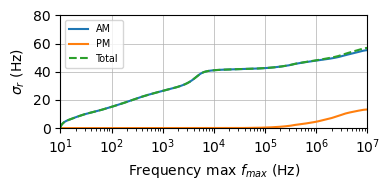

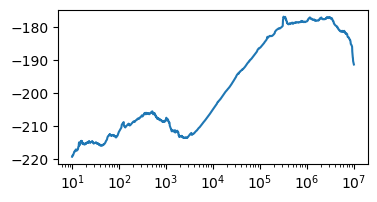

In [212]:
# Spectra to RMS of mode frequency
# Convert SSB AM noise dBc/Hz to fractional amplitude PSD
freqs = np.array(frequencies)
S_alpha = 2 * 10**(am_out / 10)

# Convert SSB phase noise dBc/Hz to phase PSD rad^2/Hz
S_phi = 2 * 10**(pn_out / 10) 

# Convert phase noise to fractional RF frequency noise
S_frac_freq = (freqs / f0)**2 * S_phi
S_frac_freq_2 = 2*10**(fm_out / 10)

# Fractional omega_r PSD
S_frac_omega_r = S_alpha + S_frac_freq
f1 = 10     # Hz
if f1 < np.min(freqs):
    print(f"Warning: f1={f1} Hz is below the minimum measured frequency {np.min(freqs):.2g} Hz. Results may be inaccurate.")
f2 = 1e7      # Hz
if f2 > np.max(freqs):
    print(f"Warning: f2={f2} Hz is above the maximum measured frequency {np.max(freqs):.2g} Hz. Results may be inaccurate.")

mask = (freqs >= f1) & (freqs <= f2)

frac_rms_error = np.sqrt(np.trapezoid(S_frac_omega_r[mask], freqs[mask]))

omega_r0 = 3e6  # your nominal radial frequency
omega_r_rms_error = omega_r0 * frac_rms_error

print("Absolute RMS omega_r error:", omega_r_rms_error)

#Get AM contribution to RMS error
frac_rms_error_am = np.sqrt(np.trapezoid(S_alpha[mask], freqs[mask]))
omega_r_rms_error_am = omega_r0 * frac_rms_error_am
print("Absolute RMS omega_r error from AM noise:", omega_r_rms_error_am)

# Get PN contribution to RMS error
frac_rms_error_pn = np.sqrt(np.trapezoid(S_frac_freq[mask], freqs[mask]))
omega_r_rms_error_pn = omega_r0 * frac_rms_error_pn
print("Absolute RMS omega_r error from PN noise:", omega_r_rms_error_pn)

# plot cumulative contributions
cumulative_am = np.sqrt(np.cumsum(S_alpha[mask] * np.diff(freqs[mask], prepend=freqs[mask][0])))* omega_r0
cumulative_pn = np.sqrt(np.cumsum(S_frac_freq[mask] * np.diff(freqs[mask], prepend=freqs[mask][0])))* omega_r0
cumulative_fm = np.sqrt(np.cumsum(S_frac_freq_2[mask] * np.diff(freqs[mask], prepend=freqs[mask][0])))* omega_r0
plt.figure(figsize=(4, 2))
plt.plot(freqs[mask], cumulative_am, label="AM")
plt.plot(freqs[mask], cumulative_pn, label="PM")
cumulative_tot = np.sqrt(cumulative_am**2 + cumulative_pn**2)
plt.plot(freqs[mask], cumulative_tot, label="Total", linestyle="--")
# plt.plot(freqs[mask], cumulative_fm, label="Cumulative RMS error from FM noise", linestyle="--")

plt.xscale("log")
plt.xlabel("Frequency max $f_{max}$ (Hz)")
plt.ylabel("$\\sigma_r$ (Hz)")
plt.grid(True, which="major", lw =0.5)
plt.xlim(1e1, 1e7)
plt.ylim(0, 80) 
path = "../../../pdf_figure/ch2/res_cumulative_noise.pdf"
plt.tight_layout()
plt.legend(fontsize="x-small")
plt.savefig(path)

# plot s freq
plt.figure(figsize=(4, 2))
SSB_freq = 10 * np.log10(S_frac_freq/2)  # Convert to dBc/Hz
plt.plot(freqs[mask], SSB_freq[mask], label="Equivalent frequency noise from PM noise")
plt.xscale("log")